# Autoencoder on synthetic rectangle images

## Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

## Dataset

Each image is 64×64, black background, one white rectangle. The rectangle is parameterized by its top-left corner $(x, y)$ and its width $w$ and height $h$ — these are the ground-truth latent factors we want the bottleneck to learn.

In [2]:
IMG_SIZE = 64
LATENT_DIM = 4

class RectangleDataset(Dataset):
    def __init__(self, n):
        self.params = []
        self.images = []
        for _ in range(n):
            x = np.random.randint(2, IMG_SIZE // 2)
            y = np.random.randint(2, IMG_SIZE // 2)
            w = np.random.randint(8, IMG_SIZE - x - 2)
            h = np.random.randint(8, IMG_SIZE - y - 2)
            img = np.zeros((1, IMG_SIZE, IMG_SIZE), dtype=np.float32)
            img[0, y:y+h, x:x+w] = 1.0
            self.images.append(img)
            self.params.append([x, y, w, h])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        return torch.tensor(self.images[i]), torch.tensor(self.params[i], dtype=torch.float32)

train_data = RectangleDataset(8000)
test_data  = RectangleDataset(500)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64)

## Data preview

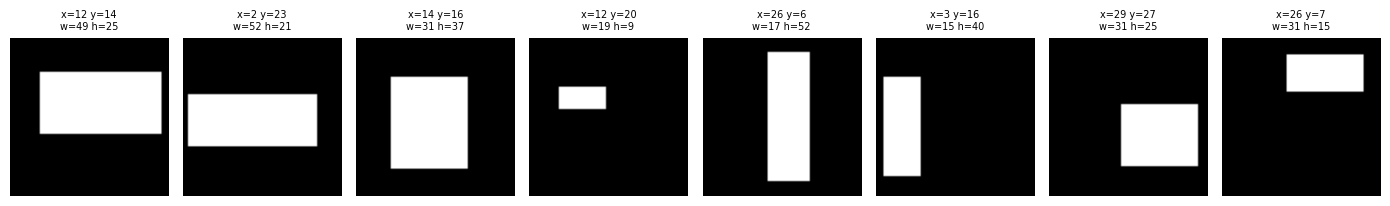

In [3]:
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    img, params = train_data[i]
    x, y, w, h = params.int().tolist()
    ax.imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'x={x} y={y}\nw={w} h={h}', fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Model

The encoder compresses the image down to a 4-dimensional bottleneck. The decoder reconstructs the image from those 4 values using transposed convolutions. The bottleneck is small enough that the network is forced to encode only the essential rectangle parameters.

In [4]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,  16, kernel_size=4, stride=2, padding=1)  # 64 -> 32
        self.conv2 = nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1)  # 32 -> 16
        self.conv3 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)  # 16 ->  8
        self.conv4 = nn.Conv2d(64, 64, kernel_size=4, stride=2, padding=1)  #  8 ->  4
        self.fc    = nn.Linear(64 * 4 * 4, LATENT_DIM)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = x.flatten(1)
        x = self.fc(x)
        return x


class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc      = nn.Linear(LATENT_DIM, 64 * 4 * 4)
        self.deconv1 = nn.ConvTranspose2d(64, 64, kernel_size=4, stride=2, padding=1)  #  4 ->  8
        self.deconv2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)  #  8 -> 16
        self.deconv3 = nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1)  # 16 -> 32
        self.deconv4 = nn.ConvTranspose2d(16,  1, kernel_size=4, stride=2, padding=1)  # 32 -> 64  (logits)
        self.relu    = nn.ReLU()

    def forward(self, z):
        x = self.relu(self.fc(z))
        x = x.view(-1, 64, 4, 4)
        x = self.relu(self.deconv1(x))
        x = self.relu(self.deconv2(x))
        x = self.relu(self.deconv3(x))
        x = self.deconv4(x)   # raw logits — sigmoid applied inside loss or at inference
        return x


class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


device = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = Autoencoder().to(device)

## Training

In [5]:
optimizer = optim.Adam(model.parameters(), lr=3e-3)

# BCE with pos_weight upweights foreground pixels (rectangles cover ~17% of pixels on average)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0]).to(device))

for epoch in range(20):
    model.train()
    total_loss = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        logits, _ = model(imgs)
        loss = loss_fn(logits, imgs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'Epoch {epoch+1:2d}  loss={total_loss / len(train_loader):.5f}')

Epoch  1  loss=0.48143
Epoch  2  loss=0.16897
Epoch  3  loss=0.11163
Epoch  4  loss=0.10707
Epoch  5  loss=0.07635
Epoch  6  loss=0.08379
Epoch  7  loss=0.09969
Epoch  8  loss=0.06677
Epoch  9  loss=0.06185
Epoch 10  loss=0.04558
Epoch 11  loss=0.04631
Epoch 12  loss=0.04268
Epoch 13  loss=0.03582
Epoch 14  loss=0.16009
Epoch 15  loss=0.03585
Epoch 16  loss=0.03082
Epoch 17  loss=0.03156
Epoch 18  loss=0.02449
Epoch 19  loss=0.12730
Epoch 20  loss=0.04183


## Reconstructions

Original (top) vs. reconstructed (bottom).

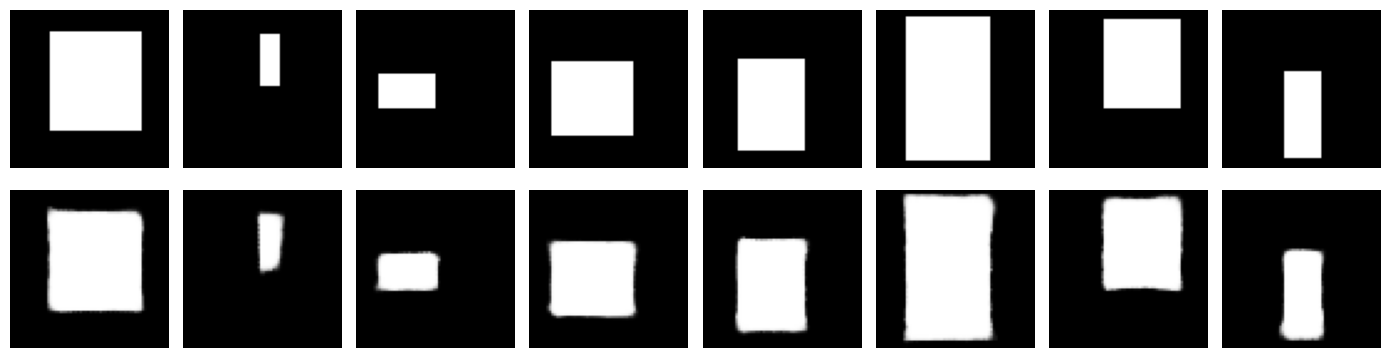

In [6]:
model.eval()
imgs, _ = next(iter(test_loader))
with torch.no_grad():
    logits, _ = model(imgs.to(device))
    recons = torch.sigmoid(logits).cpu()

n = 8
fig, axes = plt.subplots(2, n, figsize=(14, 4))
for i in range(n):
    axes[0, i].imshow(imgs[i].squeeze(),   cmap='gray', vmin=0, vmax=1)
    axes[1, i].imshow(recons[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original',      fontsize=9)
axes[1, 0].set_ylabel('Reconstructed', fontsize=9)
plt.tight_layout()
plt.show()

## Bottleneck vs. ground truth

Each bottleneck dimension is compared against the true rectangle parameter $(x, y, w, h)$. Good disentanglement shows up as tight linear relationships.

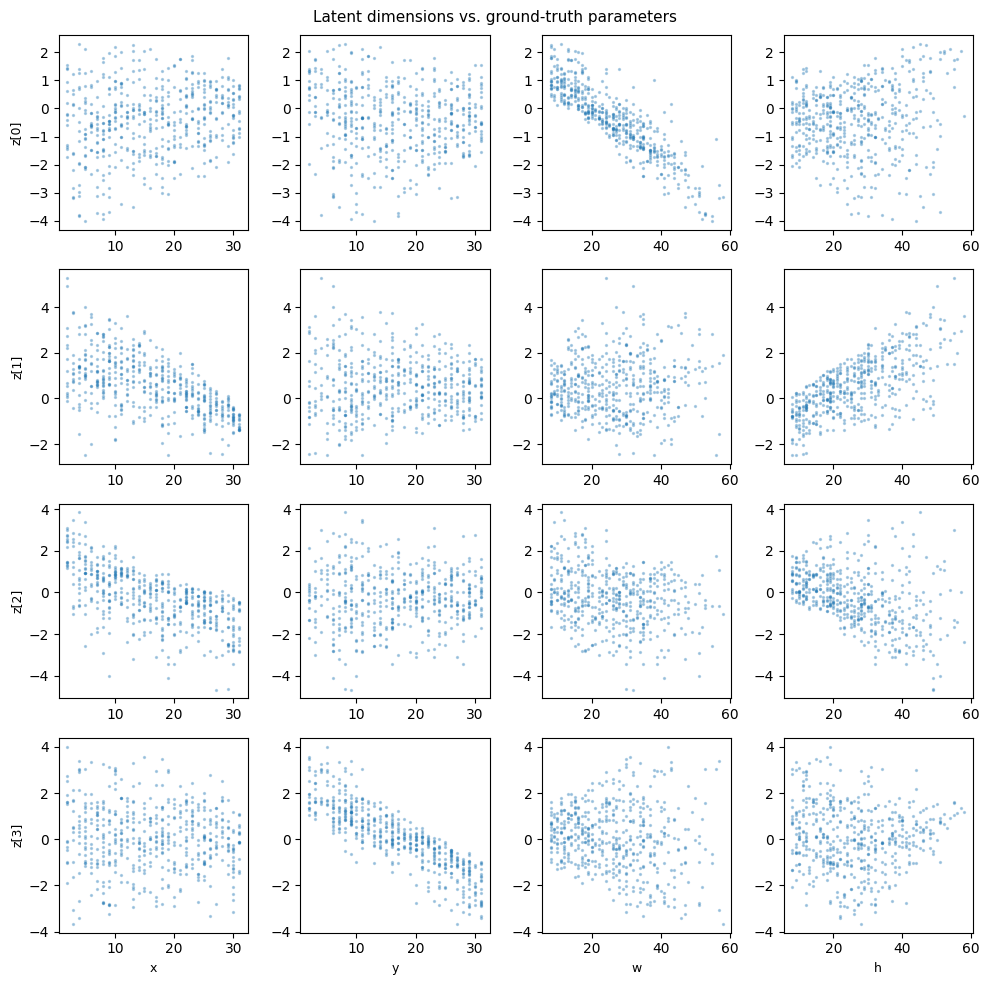

In [7]:
model.eval()
all_z, all_params = [], []
with torch.no_grad():
    for imgs, params in test_loader:
        _, z = model(imgs.to(device))
        all_z.append(z.cpu())
        all_params.append(params)

all_z      = torch.cat(all_z).numpy()
all_params = torch.cat(all_params).numpy()
param_names = ['x', 'y', 'w', 'h']

fig, axes = plt.subplots(LATENT_DIM, LATENT_DIM, figsize=(10, 10))
for row in range(LATENT_DIM):
    for col in range(LATENT_DIM):
        ax = axes[row, col]
        ax.scatter(all_params[:, col], all_z[:, row], s=2, alpha=0.3)
        if row == LATENT_DIM - 1:
            ax.set_xlabel(param_names[col], fontsize=9)
        if col == 0:
            ax.set_ylabel(f'z[{row}]', fontsize=9)
plt.suptitle('Latent dimensions vs. ground-truth parameters', fontsize=11)
plt.tight_layout()
plt.show()